<a href="https://colab.research.google.com/github/ericlakshman28/Projects-26/blob/main/rough%20work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

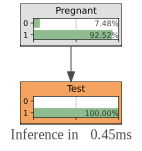

In [6]:
import pyagrum as gum
import pyagrum.lib.notebook as gnb

#create a baseyian network
bn = gum.BayesNet('Q2')

#add notes
bn.add(gum.LabelizedVariable('Pregnant', 'Is the woman pregnant?', 2))  # 0: No, 1: Yes
bn.add(gum.LabelizedVariable('Test', 'Result of the test',2)) #0: Negative, 1: Positive

#Add arcs
bn.addArc('Pregnant', 'Test')

#Set Conditional Probabilities
bn.cpt('Pregnant').fillWith([0.8, 0.2]) #P(Pregnant)
bn.cpt('Test')[{'Pregnant' : 0}] = [0.98, 0.02] #P(Test | Not Pregnant)
bn.cpt('Test')[{'Pregnant' : 1}] = [0.01, 0.99] #P(Test | Pregnant)

#run the inference computation
gnb.showInference(bn, evs={'Test' : 1})

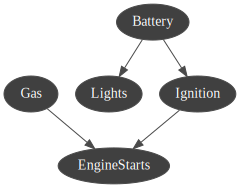

In [8]:
#create a bayesian network named 'car'
car_bn = gum.BayesNet('Car')

#add nodes for Battery
battery = car_bn.add(gum.LabelizedVariable('Battery', 'Battery',2))
car_bn.cpt(battery).fillWith([0.1,0.9])

#add nodes for lights
lights = car_bn.add(gum.LabelizedVariable('Lights', 'Lights', 2))
car_bn.addArc(battery, lights)
car_bn.cpt(lights)[{'Battery': 0}] = [1.0, 0.0]
car_bn.cpt(lights)[{'Battery': 1}] = [0.05,0.95]

#add nodes for Gas

gas = car_bn.add(gum.LabelizedVariable('Gas', 'Gas', 2))
car_bn.cpt(gas).fillWith([0.25,0.75])


#add nodes for Ignition

ignition = car_bn.add(gum.LabelizedVariable('Ignition', 'Ignition', 2))
car_bn.addArc(battery, ignition)
car_bn.cpt(ignition)[{'Battery': 0}] = [1.0, 0.0]
car_bn.cpt(ignition)[{'Battery': 1}] = [0.1, 0.9]

#add nodes for engine starts

engine_starts = car_bn.add(gum.LabelizedVariable('EngineStarts', 'EngineStarts', 2))
car_bn.addArc(ignition, engine_starts)
car_bn.addArc(gas, engine_starts)
car_bn.cpt(engine_starts)[{'Ignition': 0, 'Gas' : 0}] = [1,0]
car_bn.cpt(engine_starts)[{'Ignition': 0, 'Gas' : 1}] = [1,0]
car_bn.cpt(engine_starts)[{'Ignition': 1, 'Gas' : 0}] = [1,0]
car_bn.cpt(engine_starts)[{'Ignition': 1, 'Gas' : 1}] = [0.05, 0.95]

gnb.showBN(car_bn)